In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("pd_sweep.csv")

summary = (
    df.groupby(["Kp", "Kd"])
      .mean(numeric_only=True)
      .reset_index()
)

summary.head()

,Kp,Kd,episode,reward,mse,mae,control_cost,Max_error,final_error,settling_time,terminated,truncated,target,final_x,final_xdot
0,0.0,0.0,24.5,-90.402580,0.180974,0.332903,0.000000,0.524400,0.512552,462.86,0.08,0.92,0.0,0.082494,0.086326
1,0.0,0.1,24.5,-58.416518,0.117552,0.268684,0.022656,0.525893,0.326222,446.22,0.18,0.82,0.0,0.016797,0.019653
2,0.0,0.5,24.5,-19.555278,0.044396,0.152159,0.203562,0.525494,0.081718,344.42,0.78,0.22,0.0,-0.018165,-0.004924
3,0.0,1.0,24.5,-11.458670,0.042492,0.142315,0.682568,0.490733,0.068369,180.24,1.00,0.00,0.0,0.022538,0.004563
4,0.0,2.0,24.5,-12.069717,0.062484,0.161981,2.774638,0.557275,0.043519,118.74,1.00,0.00,0.0,-0.003344,-0.004372


In [6]:
df["success"] = df["terminated"].astype(int)
summary = (
    df.groupby(["Kp", "Kd"])
      .agg({
          "reward": "mean",
          "mse": "mean",
          "mae": "mean",
          "control_cost": "mean",
          "Max_error": "mean",
          "final_error": "mean",
          "settling_time": "mean",
          "success": "mean"
      })
      .reset_index()
)
summary.sort_values(by=["success", "mse"],ascending=[False, True]).head(20)

,Kp,Kd,reward,mse,mae,control_cost,Max_error,final_error,settling_time,success
93,64.0,1.0,-360.324121,0.026257,0.102265,107.253013,0.500054,0.027796,277.60,1.0
94,64.0,2.0,-198.013738,0.029218,0.103471,113.489004,0.522309,0.024186,146.88,1.0
84,32.0,2.0,-44.954434,0.029971,0.105985,27.802767,0.441529,0.038190,108.22,1.0
22,0.5,0.5,-12.746638,0.031487,0.130891,0.147021,0.420189,0.080907,306.24,1.0
83,32.0,1.0,-104.947624,0.033028,0.118368,33.331608,0.505484,0.044936,221.56,1.0
73,16.0,1.0,-27.081888,0.033625,0.124203,8.554566,0.429361,0.067455,154.62,1.0
95,64.0,4.0,-105.889264,0.035567,0.105291,112.555009,0.527207,0.018566,78.98,1.0
33,1.0,1.0,-10.462631,0.039799,0.134591,0.654300,0.470328,0.068808,169.84,1.0
52,4.0,0.5,-20.332598,0.040203,0.142391,0.783380,0.487134,0.083755,315.12,1.0
13,0.1,1.0,-9.706605,0.040438,0.145215,0.640615,0.479931,0.071561,182.80,1.0


In [8]:
success_heatmap = summary.pivot(index="Kp", columns="Kd", values="success")
mse_heatmap = summary.pivot(index="Kp",columns="Kd",values="mse")
settling_heatmap = summary.pivot(index="Kp",columns="Kd",values="settling_time")

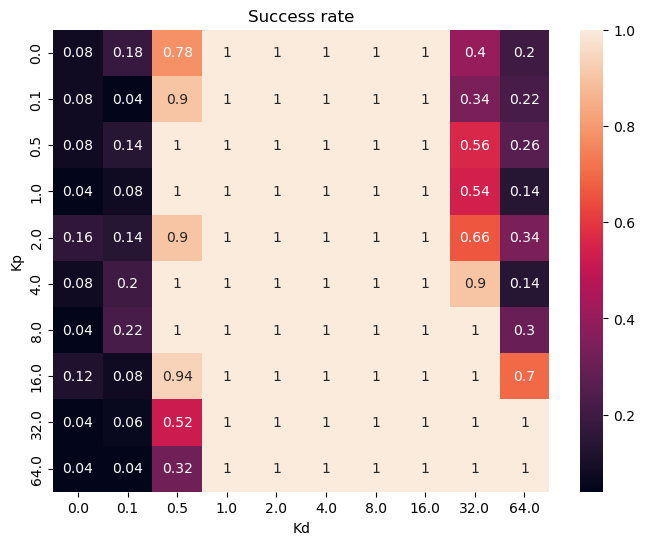

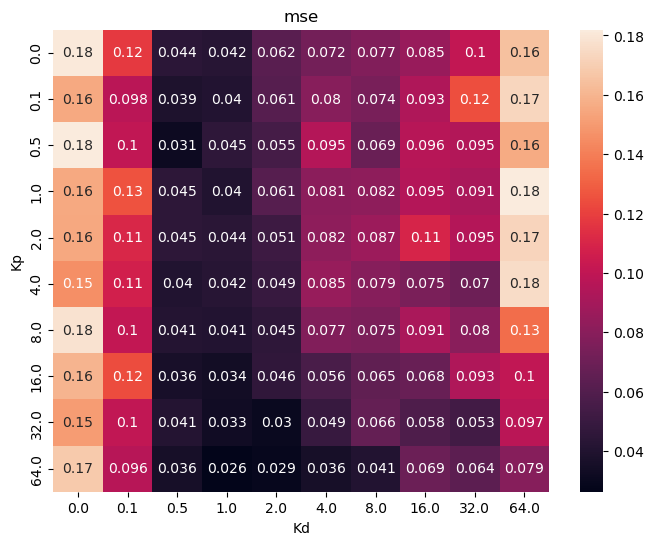

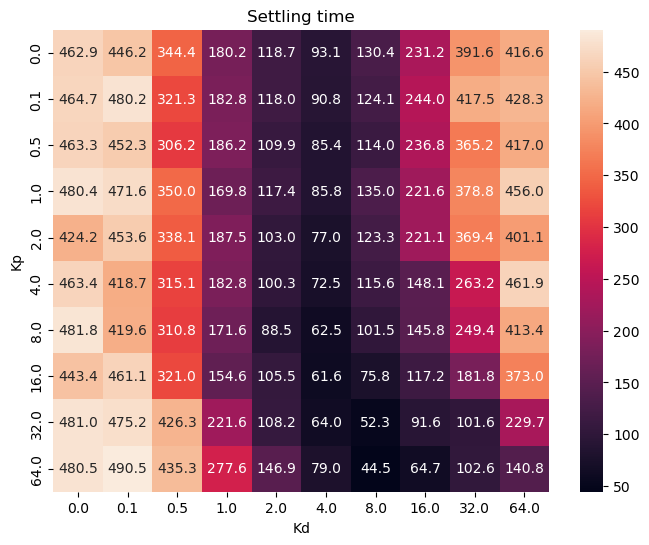

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(success_heatmap, annot=True)
plt.title("Success rate")
plt.show()
plt.figure(figsize=(8,6))
sns.heatmap(mse_heatmap, annot=True)
plt.title("mse")
plt.show()
plt.figure(figsize=(8,6))
sns.heatmap(settling_heatmap, annot=True, fmt=".1f")
plt.title("Settling time")
plt.show()

In [11]:
# --- keep only successful controllers ---
stable = summary[summary["success"] == 1.0].copy()

# --- normalize metrics (important: otherwise scales dominate unfairly) ---
stable["mse_n"] = (stable["mse"] - stable["mse"].min()) / (stable["mse"].max() - stable["mse"].min() + 1e-12)
stable["settling_n"] = (stable["settling_time"] - stable["settling_time"].min()) / (stable["settling_time"].max() - stable["settling_time"].min() + 1e-12)
stable["control_n"] = (stable["control_cost"] - stable["control_cost"].min()) / (stable["control_cost"].max() - stable["control_cost"].min() + 1e-12)

# --- weighted score (edit weights depending on what you care about most) ---
stable["score"] = (
    0.5 * stable["mse_n"] +
    0.4 * stable["settling_n"] +
    0.1 * stable["control_n"]
)

# --- best controller(s) ---
best = stable.sort_values("score").head(10)
display(best[["Kp", "Kd", "mse", "settling_time", "control_cost", "score"]])

# --- simple Pareto front (non-dominated in mse vs settling_time vs control_cost) ---
pareto = []

for i, row in stable.iterrows():
    dominated = False
    for j, other in stable.iterrows():
        if (
            (other["mse"] <= row["mse"]) and
            (other["settling_time"] <= row["settling_time"]) and
            (other["control_cost"] <= row["control_cost"]) and
            (
                (other["mse"] < row["mse"]) or
                (other["settling_time"] < row["settling_time"]) or
                (other["control_cost"] < row["control_cost"])
            )
        ):
            dominated = True
            break
    if not dominated:
        pareto.append(row)

pareto = pd.DataFrame(pareto)

display(pareto[["Kp", "Kd", "mse", "settling_time", "control_cost", "success"]])

,Kp,Kd,mse,settling_time,control_cost,score
84,32.0,2.0,0.029971,108.22,27.802767,0.130230
96,64.0,8.0,0.040774,44.46,75.850087,0.154218
64,8.0,2.0,0.045298,88.54,3.655391,0.175467
85,32.0,4.0,0.049113,64.04,33.815099,0.192979
73,16.0,1.0,0.033625,154.62,8.554566,0.195990
95,64.0,4.0,0.035567,78.98,112.555009,0.200432
74,16.0,2.0,0.045821,105.48,10.777270,0.207075
75,16.0,4.0,0.056131,61.64,10.723838,0.211734
54,4.0,2.0,0.049299,100.30,2.359485,0.213811
44,2.0,2.0,0.051245,103.00,2.254900,0.228977


,Kp,Kd,mse,settling_time,control_cost,success
13,0.1,1.0,0.040438,182.80,0.640615,1.0
22,0.5,0.5,0.031487,306.24,0.147021,1.0
33,1.0,1.0,0.039799,169.84,0.654300,1.0
35,1.0,4.0,0.080677,85.82,6.133948,1.0
44,2.0,2.0,0.051245,103.00,2.254900,1.0
45,2.0,4.0,0.081956,77.02,6.135232,1.0
54,4.0,2.0,0.049299,100.30,2.359485,1.0
55,4.0,4.0,0.085020,72.50,6.544684,1.0
64,8.0,2.0,0.045298,88.54,3.655391,1.0
65,8.0,4.0,0.077176,62.48,7.243030,1.0
